In [1]:
install.packages(setdiff(c("gridExtra", "caret", "glmnet", "margins", "pROC", "plotmo"), rownames(installed.packages())))
curl::curl_download("https://github.com/bquistorff/NABE_workbooks/raw/colab/default.zip", "default.zip")
unzip("default.zip")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘shape’, ‘RcppEigen’, ‘prediction’, ‘Formula’, ‘plotrix’




In [2]:

suppressWarnings(library(tidyverse, quietly = TRUE, warn.conflicts = FALSE))
suppressWarnings(library(caret, quietly = TRUE, warn.conflicts = FALSE))
suppressWarnings(library(mgcv, quietly = TRUE, warn.conflicts = FALSE))
suppressWarnings(require(gridExtra, quietly = TRUE, warn.conflicts = FALSE))
suppressWarnings(library(glmnet, quietly = TRUE, warn.conflicts = FALSE))
suppressWarnings(library(margins, quietly = TRUE, warn.conflicts = FALSE))
suppressWarnings(library(pROC, quietly = TRUE, warn.conflicts = FALSE))
suppressWarnings(library(plotmo, quietly = TRUE, warn.conflicts = FALSE))

set.seed(2718281)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10

Type 'citation("pROC")' for a citation.



### In this module you will learn:


1. How to classify credit card defaults based on observable characteristics
2. Examine goodness-of-fit measures for classification
3. Explore generalized additive models in R
4. Explore shrinkage of nonlinear models

### The Data

The credit card default data is from Taiwan in 2005. We don't have too many covariates to examine, but the ones we do have should be informative. Let's look at the raw data to see the names and descriptions:

| Covariate Name | Description                         |
|----------------|-------------------------------------|
| LIMIT_BAL      | Amt of credit available             |
| SEX            | Indicator for sex                   |
| AGE            | Age                                 |
| PAY            | Denotes deliquency in past periods  |                     
| BILL_AMT       | Denotes amount due in past periods  |
| PAY_AMT        | Denotes amount paid in past periods |
| educ           | Indicator for Education Level       |
| marr           | Indicator for marital status        |
| default        | Indicator for default status        |

Alright now that we know what the variable names correspond to, let's load in the data.


In [3]:
defaults = read.csv('default.csv')
# Reads csv files into R
defaults[1:10,1:10]
# Examine the first few rows of our data
cat('Dataset dimesions: ', dim(defaults))
# Returns the dimension of the dataset
defaults$default = as.factor(defaults$default)

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,20000,1,24,2,2,-1,-1,-2,-2,3913
2,120000,1,26,-1,2,0,0,0,2,2682
3,90000,1,34,0,0,0,0,0,0,29239
4,50000,1,37,0,0,0,0,0,0,46990
5,50000,0,57,-1,0,-1,0,0,0,8617
6,50000,0,37,0,0,0,0,0,0,64400
7,500000,0,29,0,0,0,0,0,0,367965
8,100000,1,23,0,-1,-1,0,0,-1,11876
9,140000,1,28,0,0,2,0,0,0,11285


Dataset dimesions:  30000 31

## Validation Split in Discrete Data

One thing we have to be careful about in classification is how we split the sample to preserve the balance of the data. Let's see what proportion of the sample actually defaults.

proportion of defaults:  0.2840267

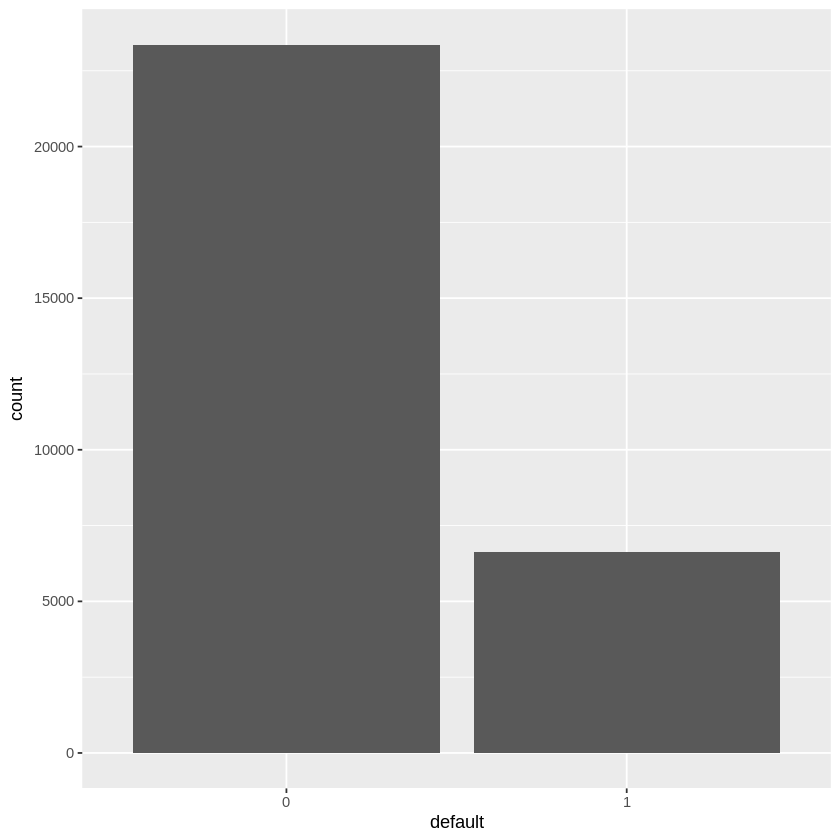

In [4]:
ggplot(defaults, aes(default)) + geom_bar()
cat('proportion of defaults: ', sum(defaults$default==1)/sum(defaults$default==0))

It looks like a bit more than $\frac{1}{4}$ of the sample defaults. As we did before, let's split our data into train-test-validation sets, but this time we are going to use the built in 'createDataPartition' function. We want to make sure that our splits preserve this proportion. This function will automatically balance the splits based on a specified covariate. In this case we are balancing on $default$.

In [5]:
## Splitting the data
trainIndex = createDataPartition(defaults$default, p = .9,
                                  list = FALSE,
                                  times = 1)
train_test = defaults[trainIndex,]
validation = defaults[-trainIndex,]


## Building a Classifier

To get started we can train a very simple classifier based only on $SEX$, $AGE$, $EDUC$, $MARR$, and $LIMIT$_$BAL$. The simple classifier will use logistic regression. This is very easy to implement in R. The only changes we have to make in the train function is to specify "glm" instead of "lm" and change the "family" to binomial. Let's examine the model.

In [6]:
train1 = cbind(train_test[c('default','SEX','AGE','LIMIT_BAL')],
               select(train_test,starts_with('educ')),
           select(train_test,starts_with('marr')))


# Lets just do a single split here into train-test

tmp = createDataPartition(train1$default, p = .8,
                                  list = FALSE,
                                  times = 1)
train_tmp = train1[tmp,]
test_tmp = train1[-tmp,]


Logistic = glm(default~., data= train_tmp, family='binomial')
#GLM (generalized linear model) with family=binomial

summary(Logistic)


Call:
glm(formula = default ~ ., family = "binomial", data = train_tmp)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.305e+01  8.893e+01  -0.147   0.8833    
SEX         -1.774e-01  3.409e-02  -5.203 1.96e-07 ***
AGE          3.884e-03  2.073e-03   1.873   0.0610 .  
LIMIT_BAL   -3.348e-06  1.574e-07 -21.266  < 2e-16 ***
educ.._1     1.113e+01  8.893e+01   0.125   0.9004    
educ.._2     1.118e+01  8.893e+01   0.126   0.8999    
educ.._3     1.114e+01  8.893e+01   0.125   0.9003    
educ.._4     9.854e+00  8.893e+01   0.111   0.9118    
educ.._5     9.529e+00  8.893e+01   0.107   0.9147    
educ.._6     1.054e+01  8.893e+01   0.118   0.9057    
marr.._1     1.238e+00  5.281e-01   2.345   0.0191 *  
marr.._2     1.033e+00  5.283e-01   1.956   0.0505 .  
marr.._3     1.073e+00  5.488e-01   1.955   0.0506 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null devianc

## Intepreting the Classifier

This is the full output from our logistic regression. Remember unlike the linear model, the coefficients themselves do not have a direct interpretation. However, we do care about the statistical significance of the parameters. We can see that in this particular specification the most important factors are sex and limit balance. These results are consistent with other findings. The "SEX" variable indicates the individual is Female and the sign is negative, i.e. Females are less likely to default than Males (ceteris paribus). Naturally, a higher limit balance should indicate a lower likelihood of default.

## What about Marginal Effects?

Since we can't directly interpret the coefficients as marginal effects we need to perform an extra step. We can get average marginal effects for all covariates in the model using the margins package.

In [7]:
m = suppressWarnings(margins(Logistic))
summary(m)

,factor,AME,SE,z,p,lower,upper
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AGE,6.486309e-04,3.461818e-04,1.8736715,6.097571e-02,-2.987287e-05,1.327135e-03
2,educ.._1,1.859078e+00,1.485282e+01,0.1251667,9.003916e-01,-2.725191e+01,3.097006e+01
3,educ.._2,1.867541e+00,1.485282e+01,0.1257365,8.999405e-01,-2.724345e+01,3.097853e+01
4,educ.._3,1.860762e+00,1.485282e+01,0.1252800,9.003018e-01,-2.725023e+01,3.097175e+01
5,educ.._4,1.645832e+00,1.485302e+01,0.1108079,9.117687e-01,-2.746555e+01,3.075721e+01
6,educ.._5,1.591545e+00,1.485301e+01,0.1071530,9.146676e-01,-2.751982e+01,3.070291e+01
7,educ.._6,1.759850e+00,1.485301e+01,0.1184844,9.056839e-01,-2.735151e+01,3.087121e+01
8,LIMIT_BAL,-5.591563e-07,2.590971e-08,-21.5809602,2.711777e-103,-6.099384e-07,-5.083742e-07
9,marr.._1,2.067962e-01,8.818583e-02,2.3450046,1.902685e-02,3.395513e-02,3.796372e-01



## Visualizing Marginal Effects

This table may be a bit overwhelming when we have many covariates. It may be easier to visualize these effects directly. Let's just examine the effects over the range of $LIMIT$_$BAL$

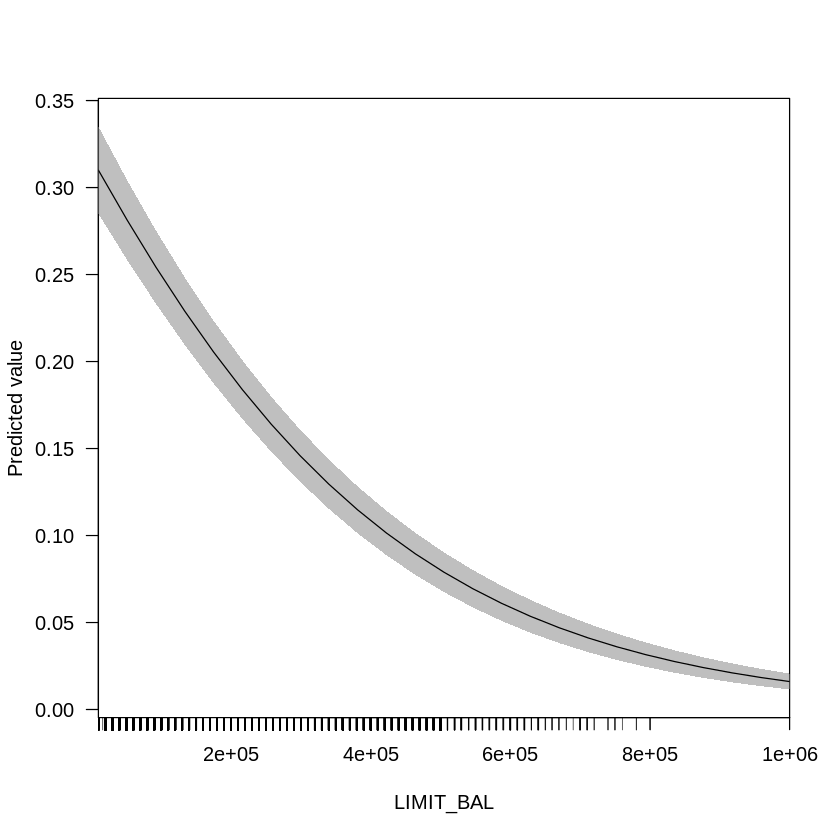

In [8]:
cplot(Logistic, "LIMIT_BAL")

As we expect the probability of default decreases with an increased limit balance, but at a decreasing rate.

## A Visualization for Goodness-of-fit

Now let's go ahead and look at the ROC (Receiver operating characteristics) curve. This is really just a way to graph the confusion matrix. The idea is to use sensitivity = True Positives / (True Positives + False Negatives) and specificity = True Negative / (True Negative + False Positive) and plot the tradeoff. Depending on the scenario in question one may prefer one over the other, but in general one wants to maximize the AUC (area under the curve).

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Training AUC:  0.6260281

Setting levels: control = 0, case = 1

Setting direction: controls < cases




 Test AUC:  0.6211977

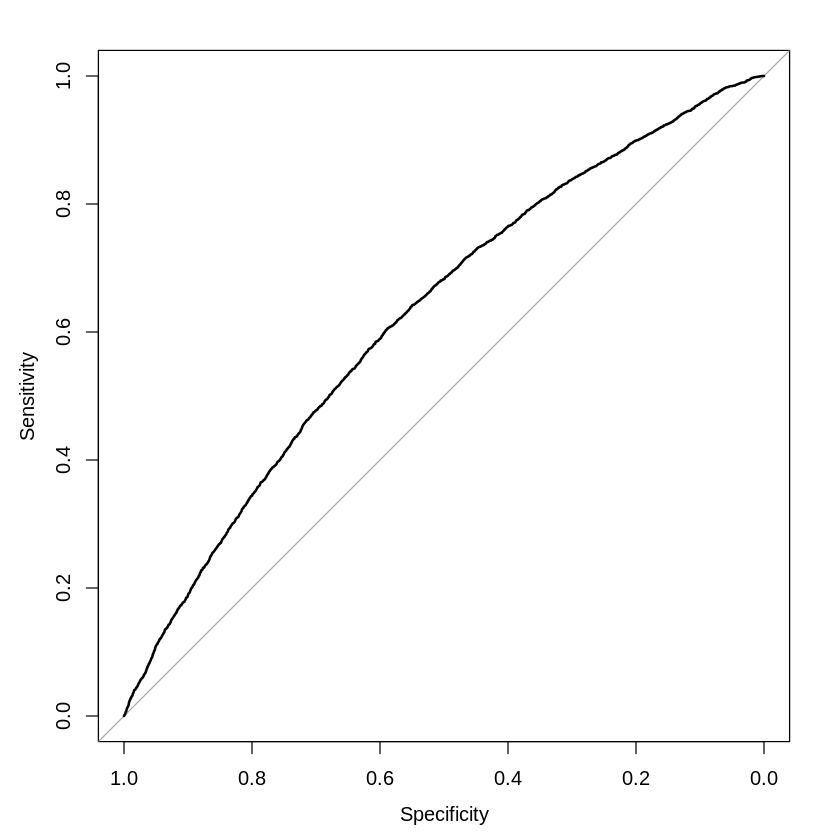

In [9]:
ROC = roc(train_tmp$default,Logistic$fitted.values)
plot(ROC)
cat('Training AUC: ', auc(ROC))

ROC = roc(test_tmp$default,predict(Logistic,newdata = test_tmp))
cat('\n Test AUC: ', auc(ROC))

## How did we do?

The simple classifier doesn't do too poorly. Training and test set performance are about the same, but we should be able to obtain better performance by including the remaining covariates. Add the covariates relating to past payment and bill balances using the select() command and run the new regression model.

In [10]:
train2 = cbind(train1,select(train_test,starts_with('PAY')),
               select(train_test,starts_with('BILL')))

tmp = createDataPartition(train2$default, p = .8,
                                  list = FALSE,
                                  times = 1)
train_tmp = train2[tmp,]
test_tmp = train2[-tmp,]

Logistic = glm(default~., data= train_tmp, family='binomial')

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


How does our ROC improve by adding these covariates?

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Training AUC:  0.7262885

Setting levels: control = 0, case = 1

Setting direction: controls < cases




 Test AUC:  0.7216857

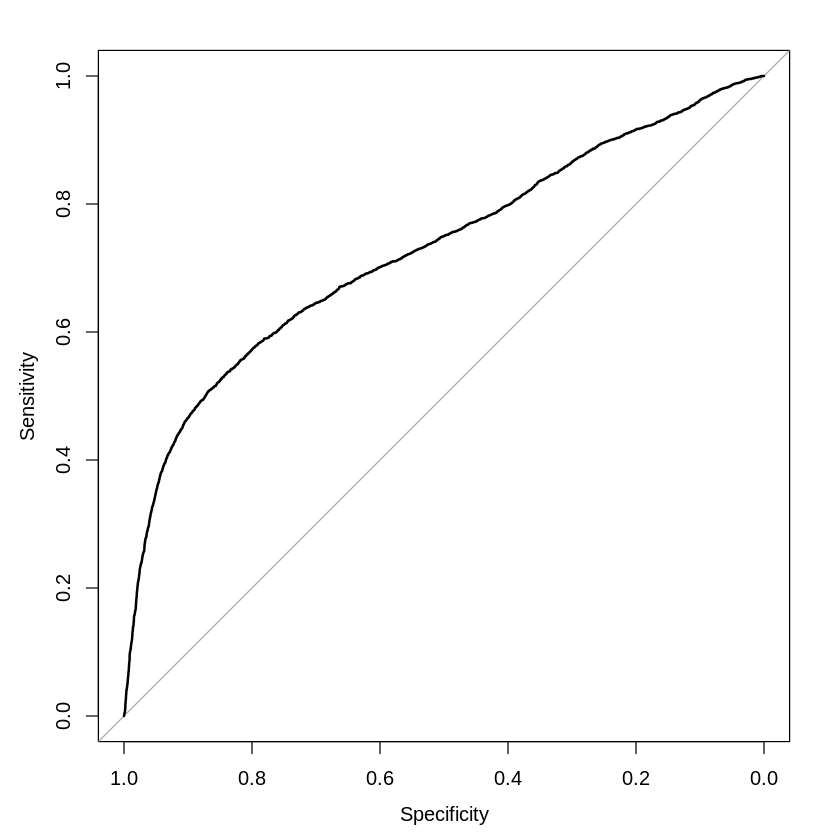

In [11]:
ROC = roc(train_tmp$default,Logistic$fitted.values)
plot(ROC)
cat('Training AUC: ', auc(ROC))

ROC = roc(test_tmp$default,predict(Logistic,newdata = test_tmp))
cat('\n Test AUC: ', auc(ROC))


## Improving our Classifier

Looks like adding the additional information helped quite a bit. However, we may be interested in other functional forms for the model.
There are many options for flexible functional forms. The most common way is to add higher order terms (polynomials) as we did in the first module. Another common method is to use a cubic spline. Let's consider a very simple extension of the previous model. The only difference will be the $LIMIT$_$BAL$ variable enters the model as an argument of an unknown function. The extension of GLM in this form is called a GAM (Generalized Additive Model).

In R we can use the GAM package to estimate these types of models. One thing to keep in mind is the formula must be specified here. The model we are looking at is exactly the same as the previous one except we apply a cubic spline to $LIMIT$_$BAL$, $PAY$_$AMT1$, and $BILL$_$AMT1$. This is denoted by "s()" with the option set to "cr".

In [12]:
formula = as.formula(paste("default~", paste(colnames(train2[, !names(train2) %in%
                    c("default","LIMIT_BAL","PAY_AMT1","BILL_AMT")]),
                    collapse="+"),'+s(LIMIT_BAL, bs="cr")',
                    '+s(PAY_AMT1, bs="cr")',
                    '+s(BILL_AMT1, bs="cr")'))

Logistic = gam(formula, data= train_tmp, family='binomial')
summary(Logistic)



Family: binomial 
Link function: logit 

Formula:
default ~ SEX + AGE + educ.._1 + educ.._2 + educ.._3 + educ.._4 + 
    educ.._5 + educ.._6 + marr.._1 + marr.._2 + marr.._3 + PAY_0 + 
    PAY_2 + PAY_3 + PAY_4 + PAY_5 + PAY_6 + PAY_AMT2 + PAY_AMT3 + 
    PAY_AMT4 + PAY_AMT5 + PAY_AMT6 + BILL_AMT1 + BILL_AMT2 + 
    BILL_AMT3 + BILL_AMT4 + BILL_AMT5 + BILL_AMT6 + s(LIMIT_BAL, 
    bs = "cr") + s(PAY_AMT1, bs = "cr") + s(BILL_AMT1, bs = "cr")

Parametric coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -6.088e+01  8.732e+05   0.000 0.999944    
SEX         -9.843e-02  3.710e-02  -2.653 0.007976 ** 
AGE          6.348e-03  2.232e-03   2.844 0.004461 ** 
educ.._1     2.853e+01  7.622e+05   0.000 0.999970    
educ.._2     2.848e+01  7.622e+05   0.000 0.999970    
educ.._3     2.845e+01  7.622e+05   0.000 0.999970    
educ.._4     2.775e+01  7.622e+05   0.000 0.999971    
educ.._5     2.743e+01  7.622e+05   0.000 0.999971    
educ.._6     2.854e+01  7.622e+0

Notice that $LIMIT$_$BAL$, $PAY$_$AMT1$, and $BILL$_$AMT1$ are now described at the end of summary and are called a "smooth term". We can once again evaluate the ROC curve for this model.

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Training AUC:  0.7572195

Setting levels: control = 0, case = 1

Setting direction: controls < cases




 Test AUC:  0.7494779

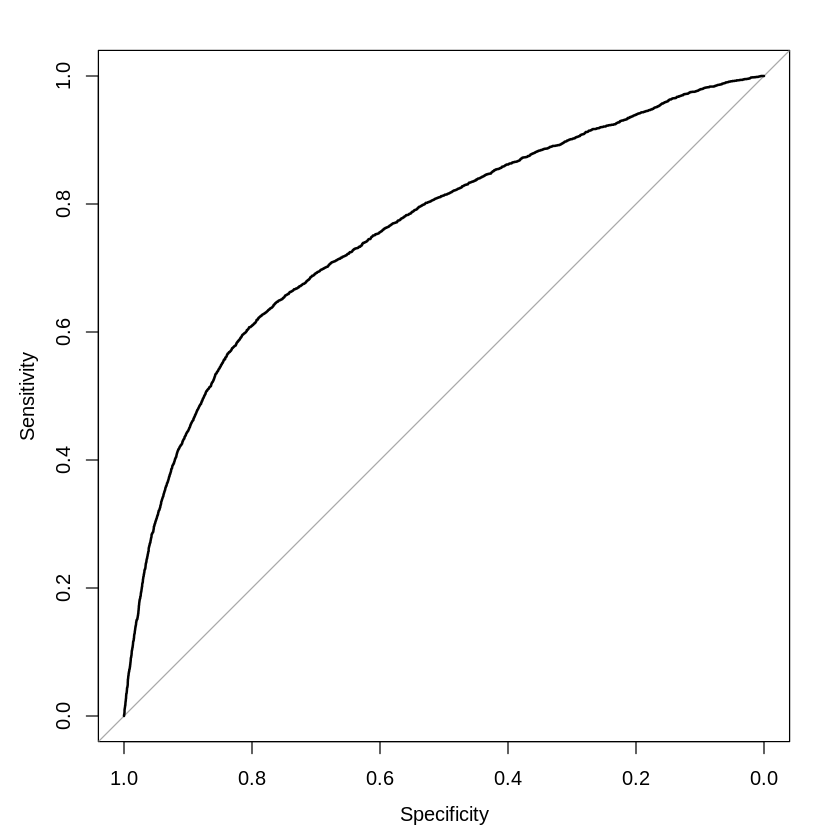

In [13]:
ROC = roc(train_tmp$default,Logistic$fitted.values)
plot(ROC)
cat('Training AUC: ', auc(ROC))

ROC = roc(test_tmp$default,predict(Logistic,newdata = test_tmp))
cat('\n Test AUC: ', auc(ROC))



## Evaluating the GAM

We get an improvement in test performance in this case. One caveat to adding smoothing terms to the model is that they can overfit. There are various ways of handling this, but penalization can and is used in this setting as well. We can do both of these things at once, but for simplicity let's go back to the full model without the smooth terms.

## Shrinkage in Nonlinear Models

The same penalty terms can be used in nonlinear models as they were in the linear case. Let's use LASSO on our model.




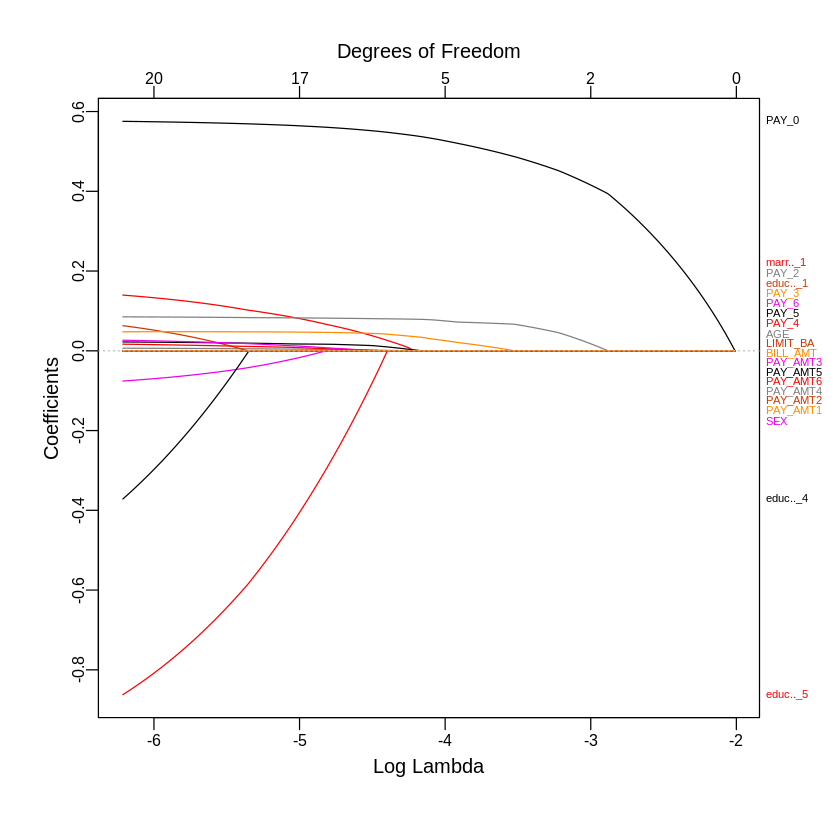

In [14]:
y = as.double(as.matrix(train_tmp$default))
x = as.matrix(train_tmp[,-1])

reg = glmnet(x, y, family='binomial', alpha=1, nlambda=1000)
cv.lasso = cv.glmnet(x, y, family='binomial', alpha=1, nfolds=5, nlambda=1000)
plot_glmnet(reg, label=TRUE, s = cv.lasso$lambda.min, xvar="lambda")



As before the coefficients are shrinking towards $0$ as the penalty increases. We see the coefficient for $PAY$_$0$ is the final value to reach zero. Although we should be careful about correlation between the independent variables, this suggests that how much an individual paid in the last period is the most important feature of our classifier (at least for this specification).

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Training AUC:  0.7201519

Setting levels: control = 0, case = 1

Setting direction: controls < cases




 Test AUC:  0.7205607

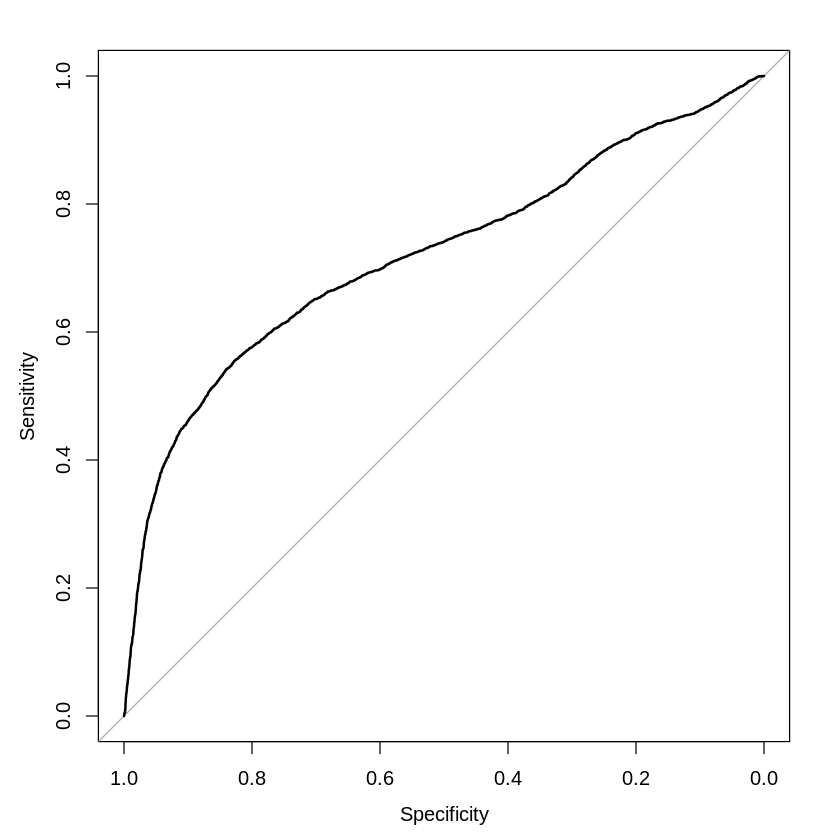

In [15]:
ROC = roc(train_tmp$default,c(predict(cv.lasso,newx=x)))
plot(ROC)
cat('Training AUC: ', auc(ROC))


xtest = as.matrix(test_tmp[,-1])
ytest = as.double(as.matrix(test_tmp$default))
ROC = roc(test_tmp$default,c(predict(cv.lasso,newx=xtest)))
cat('\n Test AUC: ', auc(ROC))



## Exercise: Module 3

In this module we saw how to split data when the outcome variable is binary to ensure proper balance across the splits. We built a simple linear classifier using logistic regression and examined the individual significance of the parameters. In addition we showed how one can compute and display marginal effects of these covariates. We introduced the concept of ROC for goodness-of-fit and examined both GAMs and shrinkage. An interesting question to ask is what would happen if we subset the sample so that the default rate is much lower, i.e. the outcome variable is very imbalanced?

1. Subsample the data such that the default rate is much lower ($0.5\%$)
2. What happens when you run the logistic regression on this data?
2. Redo the LASSO regression on this subsample
3. What do you find?


We have seen that when the proportion of non-zero to zero outcomes is very large or small we may need to consider using shrinkage methods instead of our simple linear classifier.